<a href="https://colab.research.google.com/github/dacdemon/ITD/blob/main/Practica_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 3: Diagnóstico y Saneamiento de datos de pozos petroleros.
Alumnos: Damián Coria

Comisión: 2

In [185]:
# Diagnóstico Inicial y Saneamiento técnico

# Importamos pandas y matplot

import pandas as pd
import matplotlib.pyplot as plt

# Cargamos el archivo csv desde un repositorio web

url = "https://raw.githubusercontent.com/dacdemon/ITD/refs/heads/main/practica_3.csv"
df = pd.read_csv(url)

In [186]:
# Se busca el volumen de datos original
dimensiones = df.shape
print("Dimensiones del dataset:")
print(dimensiones[0] ,"Filas")
print(dimensiones[1], "columnas")
print()
print("Tipos de datos:")
print(df.dtypes)

Dimensiones del dataset:
3000 Filas
7 columnas

Tipos de datos:
Datetime                 object
ID_Pozo                  object
Temp_Fluido_C            object
Presion_Succion_psi     float64
Presion_Descarga_psi    float64
Caudal_BPD              float64
Vibracion_mm_s          float64
dtype: object


In [187]:
# Detección de Anomalías y conteo de fallas:
# Contar los valores faltantes de cada columna
print("Valores faltantes por columna:")
print(df.isnull().sum())

Valores faltantes por columna:
Datetime                0
ID_Pozo                 0
Temp_Fluido_C           0
Presion_Succion_psi     0
Presion_Descarga_psi    0
Caudal_BPD              0
Vibracion_mm_s          0
dtype: int64


In [188]:
# Buscar duplicados:
cantidad_duplicados = df.duplicated().sum()

print("Cantidad de registros duplicados:")
print(cantidad_duplicados)

Cantidad de registros duplicados:
0


In [189]:
# Ajuste de Formatos: Datetime y Temp_Fluido_C aparecen como texto

df["Datetime"] = pd.to_datetime(df["Datetime"])
df["Temp_Fluido_C"] = pd.to_numeric(df["Temp_Fluido_C"], errors="coerce")

# Mostrar los tipos de datos nuevamente
print("Tipos de datos después de la conversión:")
tiempo = df["Datetime"].dtype
temp = df["Temp_Fluido_C"].dtypes
print("El formato de la columna Datetime es: ", tiempo)
print("El formato de la columna Temp_Fluido_C es: ", temp)
# Comprobar nuevamente valores faltantes tras la conversión
print("Valores faltantes después de la conversión:")
print(df.isnull().sum())



Tipos de datos después de la conversión:
El formato de la columna Datetime es:  datetime64[ns]
El formato de la columna Temp_Fluido_C es:  float64
Valores faltantes después de la conversión:
Datetime                0
ID_Pozo                 0
Temp_Fluido_C           1
Presion_Succion_psi     0
Presion_Descarga_psi    0
Caudal_BPD              0
Vibracion_mm_s          0
dtype: int64


#Registros faltantes: ¿Qué hacemos en ese caso? consideremos usar la media o la mediana?
En caso de registros faltantes lo remplazaremos con la mediana ya que no lo afectan valores extremos.

In [190]:
# Se detecto un valor faltante y se remplaza por la mediana

mediana_temp = df["Temp_Fluido_C"].median()
df["Temp_Fluido_C"] = df["Temp_Fluido_C"].fillna(mediana_temp)
print("La mediana de los valores de temperatura es", round(mediana_temp,2))
print("Se reemplaza el valor faltante y volvemos a verificar")
print(df.isnull().sum())


La mediana de los valores de temperatura es 85.0
Se reemplaza el valor faltante y volvemos a verificar
Datetime                0
ID_Pozo                 0
Temp_Fluido_C           0
Presion_Succion_psi     0
Presion_Descarga_psi    0
Caudal_BPD              0
Vibracion_mm_s          0
dtype: int64


# Outliers (seguimos con la limpieza)

In [191]:
# Primero vamos a mirar los valores mínimos y máximos.
print("Estadísticas descriptivas:")
print(df.describe())

Estadísticas descriptivas:
                            Datetime  Temp_Fluido_C  Presion_Succion_psi  \
count                           3000    3000.000000          3000.000000   
mean   2026-03-12 11:15:00.000000256      85.039633            50.335726   
min              2026-03-09 00:00:00      78.585905            23.074473   
25%              2026-03-10 17:37:30      83.704779            48.949540   
50%              2026-03-12 11:15:00      84.997415            50.003883   
75%              2026-03-14 04:52:30      86.328089            51.009209   
max              2026-03-15 22:30:00      91.523230            94.937982   
std                              NaN       1.982964             5.842141   

       Presion_Descarga_psi   Caudal_BPD  Vibracion_mm_s  
count           3000.000000  3000.000000     3000.000000  
mean             445.576920   117.684097        1.616954  
min              214.965972    75.383041        0.737939  
25%              440.307535   117.332168        1.36

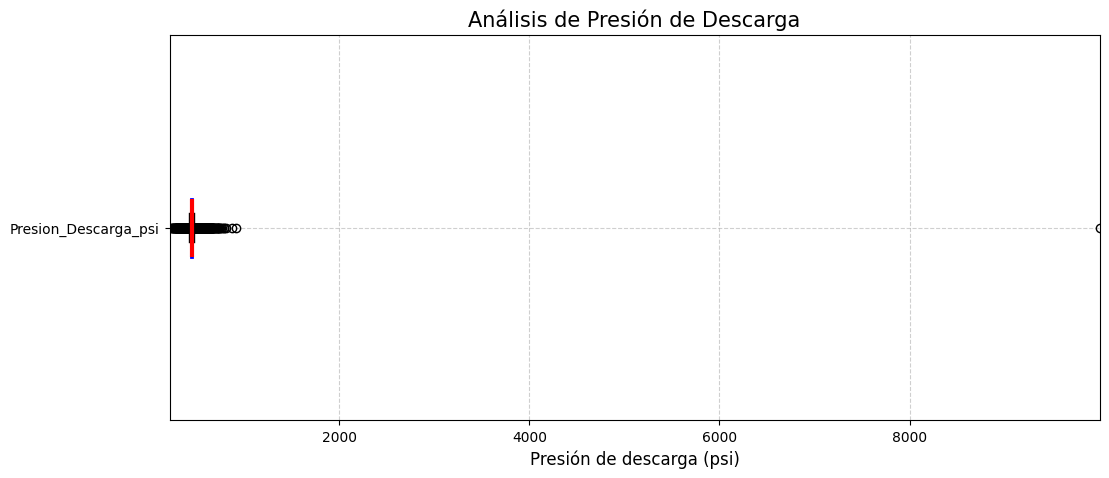

In [192]:
# Se crea un bloxplot para analizar presion_descarga_psi ya que se encontro el valor 9999
plt.figure(figsize=(12, 5))
df.boxplot(column=['Presion_Descarga_psi'],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#D6EAF8', color='blue', linewidth=2),
    medianprops=dict(color='red', linewidth=3))

plt.xlim(df['Presion_Descarga_psi'].min(),
    df['Presion_Descarga_psi'].max())
plt.title('Análisis de Presión de Descarga', fontsize=15)
plt.xlabel('Presión de descarga (psi)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#Diagnóstico: Si la caja es tan pequeña que parece una línea, significa que el proceso es extremadamente estable en el día a día, y que el valor de 9999 psi puede ser una anomalía total (un outlier).

In [193]:
# se detecto un outlier, se procede a su reemplazo por la mediana

presion_anormal = df[df["Presion_Descarga_psi"] == 9999]
fila_anormal = presion_anormal.index[0]
print("Registro con presión de descarga igual a 9999 psi:")
print(presion_anormal)
print("La fila con el valor anormal es la numero", fila_anormal)

# Calculamos la mediana y reemplazamos

mediana_presion = df["Presion_Descarga_psi"].median()

df["Presion_Descarga_psi"] = df["Presion_Descarga_psi"].replace(9999, mediana_presion)

print("La mediana de los valores de presion es", round(mediana_presion,2))
print("Se reemplaza el valor de 9999 psi por su mediana y lo verificamos:")
print(df.loc[50])


Registro con presión de descarga igual a 9999 psi:
              Datetime ID_Pozo  Temp_Fluido_C  Presion_Succion_psi  \
50 2026-03-09 02:40:00    P-03      81.736616            69.551407   

    Presion_Descarga_psi  Caudal_BPD  Vibracion_mm_s  
50                9999.0  116.670936        1.532595  
La fila con el valor anormal es la numero 50
La mediana de los valores de presion es 449.13
Se reemplaza el valor de 9999 psi por su mediana y lo verificamos:
Datetime                2026-03-09 02:40:00
ID_Pozo                                P-03
Temp_Fluido_C                     81.736616
Presion_Succion_psi               69.551407
Presion_Descarga_psi             449.130733
Caudal_BPD                       116.670936
Vibracion_mm_s                     1.532595
Name: 50, dtype: object


In [194]:
# Se realiza una copia para conservar el dataset original.

df_limpio = df.copy()

print("Se creó el DataFrame df_limpio para trabajar con los datos.")

Se creó el DataFrame df_limpio para trabajar con los datos.


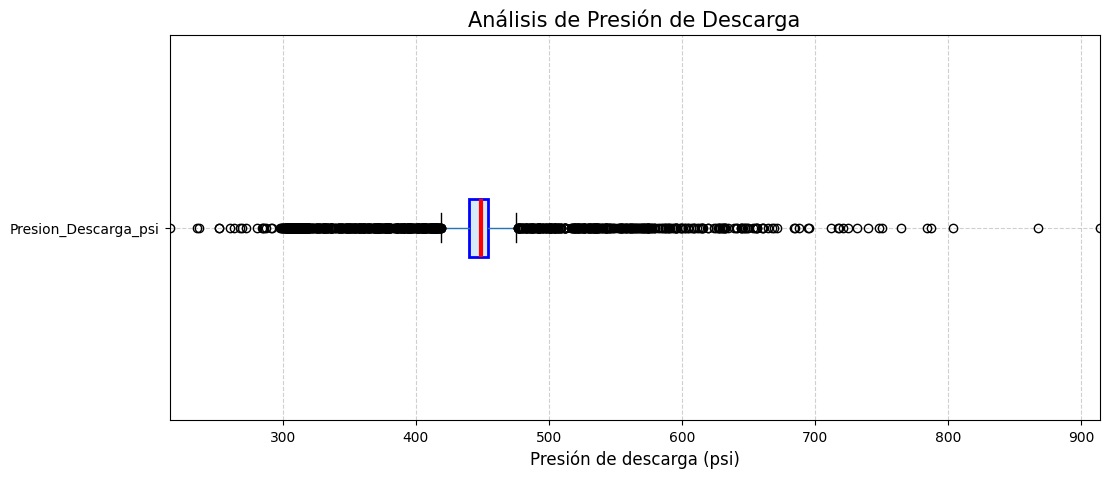

In [195]:
# Se vuelve a lanzar el mismo bloxplot con el valor corregido
plt.figure(figsize=(12, 5))
df_limpio.boxplot(column=['Presion_Descarga_psi'],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#D6EAF8', color='blue', linewidth=2),
    medianprops=dict(color='red', linewidth=3))

# Mostramos todo el rango de presión
plt.xlim(df_limpio['Presion_Descarga_psi'].min(),
    df_limpio['Presion_Descarga_psi'].max())
plt.title('Análisis de Presión de Descarga', fontsize=15)
plt.xlabel('Presión de descarga (psi)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#Conclusion: se elimino el outlier y se observan Puntos fuera de los bigotes: Se Requiere inspección física inmediata.

In [196]:
# Estadística Descriptiva
#Caudal_BPD significa Caudal en Barriles por Día

fecha_inicio = df_limpio["Datetime"].min()
fecha_fin = df_limpio["Datetime"].max()
periodo_total = fecha_fin - fecha_inicio
print("PERÍODOS DE REGISTRO")
print("Primer registro: ", fecha_inicio)
print("Último registro: ", fecha_fin)
print("Período total: ", periodo_total)


PERÍODOS DE REGISTRO
Primer registro:  2026-03-09 00:00:00
Último registro:  2026-03-15 22:30:00
Período total:  6 days 22:30:00


In [198]:
def calcular_caudal_pozos(df_limpio):
    suma_p01 = 0
    suma_p02 = 0
    suma_p03 = 0

    i = 0
    total_filas = len(df_limpio)

    while i < total_filas:
      if df_limpio.loc[i, "ID_Pozo"] =='p-01':
        suma_p01 = suma_p01 + df_limpio.loc[i, "Caudal_BPD"]
      elif df_limpio.loc[i, "ID_Pozo"] =='p-02':
        suma_p02 = suma_p02 + df_limpio.loc[i, "Caudal_BPD"]
      elif df_limpio.loc[i, "ID_Pozo"] =='p-03':
        suma_p02 = suma_p02 + df_limpio.loc[i, "Caudal_BPD"]
      i = i + 1
    return suma_p01


    print(suma_p01)
    print(suma_p02)
    print(suma_p03)